In [1]:
# -------------------------
# Load cleaned experiment data
# -------------------------
#
# This notebook starts the causal / uplift modeling phase.
#
# Goal:
# Estimate how customer outcomes CHANGE because of treatment.
#
# Instead of asking:
# "Who is likely to convert?"
#
# we now ask:
# "Who is more likely to convert BECAUSE we send an email?"

import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/hillstrom_clean.csv"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (64000, 13)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,purchase_preference
0,10,2) $100 - $200,142.44,1,0,Suburban,0,Phone,Womens E-Mail,0,0,0.0,Mens Only
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,Both
2,7,2) $100 - $200,180.65,0,1,Suburban,1,Web,Womens E-Mail,0,0,0.0,Womens Only
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,Mens Only
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,Mens Only


In [2]:
# -------------------------
# Define causal modeling inputs
# -------------------------
#
# We have 3 treatment groups:
#
# 1. No E-Mail      -> control
# 2. Mens E-Mail    -> treatment option A
# 3. Womens E-Mail  -> treatment option B
#
# Our main outcome for the first uplift model will be:
# conversion
#
# We only use PRE-TREATMENT customer information as features.
# That means we do NOT use:
# visit, conversion, or spend as input features.

feature_columns = [
    "recency",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
    "purchase_preference"
]

treatment_column = "segment"
outcome_column = "conversion"

X = df[feature_columns].copy()
treatment = df[treatment_column].copy()
y = df[outcome_column].copy()

print("Features:")
print(feature_columns)

print("\nTreatment groups:")
print(treatment.value_counts())

print("\nOverall conversion rate:")
print(y.mean())

Features:
['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'purchase_preference']

Treatment groups:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Overall conversion rate:
0.00903125


In [3]:
# -------------------------
# Create a binary causal dataset:
# Mens E-Mail vs No E-Mail
# -------------------------
#
# We temporarily exclude Womens E-Mail customers.
#
# Treatment encoding:
# 1 = Mens E-Mail
# 0 = No E-Mail
#
# Outcome:
# 1 = converted
# 0 = did not convert

mens_df = df[
    df["segment"].isin([
        "Mens E-Mail",
        "No E-Mail"
    ])
].copy()

# Binary treatment indicator.
mens_df["treatment_mens"] = (
    mens_df["segment"] == "Mens E-Mail"
).astype(int)

print("Binary dataset shape:", mens_df.shape)

print("\nTreatment counts:")
print(mens_df["treatment_mens"].value_counts())

print("\nConversion rate by treatment:")
print(
    mens_df.groupby("treatment_mens")["conversion"].mean()
)

Binary dataset shape: (42613, 14)

Treatment counts:
treatment_mens
1    21307
0    21306
Name: count, dtype: int64

Conversion rate by treatment:
treatment_mens
0    0.005726
1    0.012531
Name: conversion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split

# -------------------------
# Train/test split for uplift modeling
# -------------------------
#
# We need to keep treatment and control customers
# represented in both training and test sets.
#
# We also want conversion rates to stay reasonably balanced
# across the split.
#
# To help with that, we stratify using BOTH:
# - treatment assignment
# - conversion outcome

mens_df["stratify_group"] = (
    mens_df["treatment_mens"].astype(str)
    + "_"
    + mens_df["conversion"].astype(str)
)

mens_train, mens_test = train_test_split(
    mens_df,
    test_size=0.20,
    random_state=42,
    stratify=mens_df["stratify_group"]
)

print("Training rows:", len(mens_train))
print("Test rows:", len(mens_test))

print("\nTraining treatment counts:")
print(mens_train["treatment_mens"].value_counts())

print("\nTest treatment counts:")
print(mens_test["treatment_mens"].value_counts())

print("\nTest conversion rates by treatment:")
print(
    mens_test.groupby("treatment_mens")["conversion"].mean()
)

Training rows: 34090
Test rows: 8523

Training treatment counts:
treatment_mens
0    17045
1    17045
Name: count, dtype: int64

Test treatment counts:
treatment_mens
1    4262
0    4261
Name: count, dtype: int64

Test conversion rates by treatment:
treatment_mens
0    0.005632
1    0.012670
Name: conversion, dtype: float64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -------------------------
# Prepare preprocessing for the T-Learner
# -------------------------
#
# We use only information that existed BEFORE treatment.

numeric_features = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie"
]

categorical_features = [
    "zip_code",
    "channel",
    "purchase_preference"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# -------------------------
# Build the two T-Learner models
# -------------------------
#
# control_model learns:
# P(conversion | No E-Mail)
#
# treatment_model learns:
# P(conversion | Men's E-Mail)

control_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

treatment_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("T-Learner models created.")

T-Learner models created.


In [6]:
# -------------------------
# Train the T-Learner
# -------------------------
#
# We split the TRAINING data into:
#
# 1. Control customers:
#    people who received No E-Mail
#
# 2. Treatment customers:
#    people who received Men's E-Mail
#
# Then we train one conversion model on each group.

control_train = mens_train[
    mens_train["treatment_mens"] == 0
].copy()

treatment_train = mens_train[
    mens_train["treatment_mens"] == 1
].copy()


# Features for control customers.
X_control_train = control_train[feature_columns]

# Conversion outcome for control customers.
y_control_train = control_train["conversion"]


# Features for treated customers.
X_treatment_train = treatment_train[feature_columns]

# Conversion outcome for treated customers.
y_treatment_train = treatment_train["conversion"]


# Train the control model.
control_model.fit(
    X_control_train,
    y_control_train
)

# Train the treatment model.
treatment_model.fit(
    X_treatment_train,
    y_treatment_train
)

print("Control model trained on:", len(control_train), "customers")
print("Treatment model trained on:", len(treatment_train), "customers")
print("T-Learner training complete.")

Control model trained on: 17045 customers
Treatment model trained on: 17045 customers
T-Learner training complete.


In [7]:
# -------------------------
# Estimate individual uplift on the hidden test set
# -------------------------
#
# For every customer, we ask BOTH models:
#
# "What is the probability this person converts
# if they receive NO email?"
#
# and
#
# "What is the probability this person converts
# if they receive the Men's Email?"
#
# Estimated uplift =
# P(conversion | Men's Email)
# -
# P(conversion | No E-Mail)

X_mens_test = mens_test[feature_columns].copy()

# Predicted conversion probability under control.
pred_control = control_model.predict_proba(
    X_mens_test
)[:, 1]

# Predicted conversion probability under treatment.
pred_treatment = treatment_model.predict_proba(
    X_mens_test
)[:, 1]

# Individual estimated treatment effect / uplift.
estimated_uplift = (
    pred_treatment - pred_control
)

# Store everything in a convenient results table.
mens_uplift_results = mens_test.copy()

mens_uplift_results["pred_control"] = pred_control
mens_uplift_results["pred_treatment"] = pred_treatment
mens_uplift_results["estimated_uplift"] = estimated_uplift

print("Customers scored:", len(mens_uplift_results))

print("\nAverage predicted control conversion probability:")
print(mens_uplift_results["pred_control"].mean())

print("\nAverage predicted treatment conversion probability:")
print(mens_uplift_results["pred_treatment"].mean())

print("\nAverage estimated uplift:")
print(mens_uplift_results["estimated_uplift"].mean())

print("\nEstimated uplift summary:")
print(
    mens_uplift_results["estimated_uplift"].describe()
)

Customers scored: 8523

Average predicted control conversion probability:
0.005826239000881425

Average predicted treatment conversion probability:
0.01260497124541736

Average estimated uplift:
0.006778732244535937

Estimated uplift summary:
count    8523.000000
mean        0.006779
std         0.003575
min        -0.025125
25%         0.005084
50%         0.006062
75%         0.007407
max         0.029717
Name: estimated_uplift, dtype: float64


In [8]:
# -------------------------
# Evaluate uplift ranking using deciles
# -------------------------
#
# We sort customers from LOWEST predicted uplift
# to HIGHEST predicted uplift.
#
# Then we divide them into 10 equally sized groups.
#
# Decile 1:
# customers predicted to benefit the least
#
# Decile 10:
# customers predicted to benefit the most
#
# Because treatment was randomized, we can compare the
# REAL conversion rate of treated vs control customers
# inside each decile.

mens_uplift_results["uplift_decile"] = pd.qcut(
    mens_uplift_results["estimated_uplift"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_rows = []

for decile in sorted(
    mens_uplift_results["uplift_decile"].unique()
):
    decile_data = mens_uplift_results[
        mens_uplift_results["uplift_decile"] == decile
    ]

    treated = decile_data[
        decile_data["treatment_mens"] == 1
    ]

    control = decile_data[
        decile_data["treatment_mens"] == 0
    ]

    treated_conversion = treated["conversion"].mean()
    control_conversion = control["conversion"].mean()

    actual_uplift = (
        treated_conversion - control_conversion
    )

    decile_rows.append({
        "uplift_decile": decile,
        "customers": len(decile_data),
        "avg_predicted_uplift":
            decile_data["estimated_uplift"].mean(),
        "treated_conversion_rate":
            treated_conversion,
        "control_conversion_rate":
            control_conversion,
        "actual_uplift":
            actual_uplift
    })

uplift_decile_table = pd.DataFrame(decile_rows)

uplift_decile_table

,uplift_decile,customers,avg_predicted_uplift,treated_conversion_rate,control_conversion_rate,actual_uplift
0,1,855,0.001909,0.027273,0.009639,0.017634
1,2,850,0.004516,0.006881,0.004831,0.002050
2,3,856,0.005074,0.004785,0.002283,0.002502
3,4,850,0.005529,0.011186,0.009926,0.001260
4,5,851,0.005839,0.004494,0.009852,-0.005358
5,6,853,0.006331,0.004975,0.008869,-0.003894
6,7,851,0.006763,0.009547,0.002315,0.007232
7,8,852,0.007433,0.016548,0.000000,0.016548
8,9,852,0.009075,0.012315,0.000000,0.012315
9,10,853,0.015324,0.028169,0.009368,0.018801


In [9]:
# -------------------------
# Build a cumulative uplift / gain table
# -------------------------
#
# Business question:
#
# If we rank customers from highest predicted uplift
# to lowest predicted uplift...
#
# how much incremental conversion do we observe as
# we target more and more customers?
#
# A good uplift model should concentrate incremental
# conversions near the TOP of the ranking.


# Sort from highest predicted uplift to lowest.
ranked_uplift = mens_uplift_results.sort_values(
    "estimated_uplift",
    ascending=False
).reset_index(drop=True)


# Create percentile buckets:
# 1 = top 10% highest predicted uplift
# 10 = bottom 10%.
ranked_uplift["targeting_decile"] = pd.qcut(
    ranked_uplift.index,
    q=10,
    labels=False
) + 1


cumulative_rows = []

for k in range(1, 11):

    # Select top k deciles.
    selected = ranked_uplift[
        ranked_uplift["targeting_decile"] <= k
    ]

    treated = selected[
        selected["treatment_mens"] == 1
    ]

    control = selected[
        selected["treatment_mens"] == 0
    ]

    # Actual conversion rates inside the selected customers.
    treated_rate = treated["conversion"].mean()
    control_rate = control["conversion"].mean()

    # Observed treatment lift.
    cumulative_uplift = (
        treated_rate - control_rate
    )

    # Estimate incremental conversions created by treatment.
    #
    # treated customers
    # ×
    # treatment effect
    incremental_conversions = (
        len(treated) * cumulative_uplift
    )

    cumulative_rows.append({
        "targeted_percent": k * 10,
        "customers_targeted": len(selected),
        "treated_customers": len(treated),
        "control_customers": len(control),
        "treated_conversion_rate": treated_rate,
        "control_conversion_rate": control_rate,
        "cumulative_uplift": cumulative_uplift,
        "estimated_incremental_conversions":
            incremental_conversions
    })


cumulative_uplift_table = pd.DataFrame(
    cumulative_rows
)

cumulative_uplift_table

,targeted_percent,customers_targeted,treated_customers,control_customers,treated_conversion_rate,control_conversion_rate,cumulative_uplift,estimated_incremental_conversions
0,10,853,426,427,0.028169,0.009368,0.018801,8.009368
1,20,1705,832,873,0.020433,0.004582,0.015851,13.187858
2,30,2557,1255,1302,0.019124,0.003072,0.016051,20.144393
3,40,3409,1674,1735,0.016726,0.002882,0.013845,23.175793
4,50,4262,2077,2185,0.014444,0.004119,0.010325,21.444851
5,60,5114,2522,2592,0.012688,0.005015,0.007673,19.351080
6,70,5966,2970,2996,0.012458,0.005674,0.006784,20.147530
7,80,6818,3386,3432,0.011518,0.005245,0.006273,21.241259
8,90,7670,3822,3848,0.010989,0.005198,0.005792,22.135135
9,100,8523,4262,4261,0.012670,0.005632,0.007038,29.994368


In [10]:
# -------------------------
# Compare uplift targeting against random targeting
# -------------------------
#
# If targeting were random, then targeting X% of customers
# should generate approximately X% of the total incremental
# conversions.
#
# This gives us a simple benchmark line.

# Overall treatment effect in the full hidden test set.
overall_treated_rate = mens_test.loc[
    mens_test["treatment_mens"] == 1,
    "conversion"
].mean()

overall_control_rate = mens_test.loc[
    mens_test["treatment_mens"] == 0,
    "conversion"
].mean()

overall_test_uplift = (
    overall_treated_rate - overall_control_rate
)

# Total incremental conversions if all treated customers
# were considered.
total_treated_customers = (
    mens_test["treatment_mens"] == 1
).sum()

total_incremental_conversions = (
    total_treated_customers
    * overall_test_uplift
)

# Add the random-targeting expectation.
cumulative_uplift_table["random_incremental_conversions"] = (
    cumulative_uplift_table["targeted_percent"] / 100
    * total_incremental_conversions
)

# Calculate how much better the model ranking is than random.
cumulative_uplift_table["gain_over_random"] = (
    cumulative_uplift_table[
        "estimated_incremental_conversions"
    ]
    -
    cumulative_uplift_table[
        "random_incremental_conversions"
    ]
)

print("Overall test uplift:", overall_test_uplift)
print(
    "Total estimated incremental conversions:",
    total_incremental_conversions
)

cumulative_uplift_table[
    [
        "targeted_percent",
        "estimated_incremental_conversions",
        "random_incremental_conversions",
        "gain_over_random"
    ]
]

Overall test uplift: 0.007037627292201233
Total estimated incremental conversions: 29.994367519361656


,targeted_percent,estimated_incremental_conversions,random_incremental_conversions,gain_over_random
0,10,8.009368,2.999437,5.009931
1,20,13.187858,5.998874,7.188984
2,30,20.144393,8.998310,11.146083
3,40,23.175793,11.997747,11.178045
4,50,21.444851,14.997184,6.447667
5,60,19.351080,17.996621,1.354460
6,70,20.147530,20.996057,-0.848527
7,80,21.241259,23.995494,-2.754235
8,90,22.135135,26.994931,-4.859796
9,100,29.994368,29.994368,0.000000


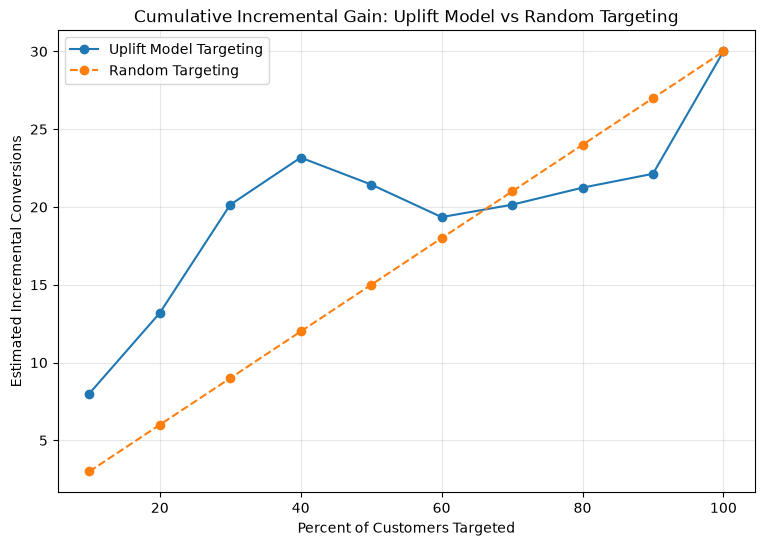

In [11]:
import matplotlib.pyplot as plt

# -------------------------
# Plot cumulative incremental conversions
# -------------------------
#
# We compare:
#
# 1. Model-based targeting
# 2. Random targeting
#
# If the model line is ABOVE the random line,
# the uplift model is creating value.

plt.figure(figsize=(9, 6))

plt.plot(
    cumulative_uplift_table["targeted_percent"],
    cumulative_uplift_table["estimated_incremental_conversions"],
    marker="o",
    label="Uplift Model Targeting"
)

plt.plot(
    cumulative_uplift_table["targeted_percent"],
    cumulative_uplift_table["random_incremental_conversions"],
    marker="o",
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Percent of Customers Targeted")
plt.ylabel("Estimated Incremental Conversions")
plt.title("Cumulative Incremental Gain: Uplift Model vs Random Targeting")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [12]:
# -------------------------
# Compute a simple Qini-style score
# -------------------------
#
# Idea:
#
# Measure the area between:
# 1. our uplift-model cumulative gain curve
# 2. the random-targeting baseline
#
# Positive area = model beats random overall.
#
# This is a simplified Qini-style summary that is
# easy to explain in the project.

import numpy as np

x = cumulative_uplift_table["targeted_percent"].values

model_gain = cumulative_uplift_table[
    "estimated_incremental_conversions"
].values

random_gain = cumulative_uplift_table[
    "random_incremental_conversions"
].values

# Area under each curve.
model_area = np.trapezoid(
    model_gain,
    x
)

random_area = np.trapezoid(
    random_gain,
    x
)

# Area between model and random.
qini_style_score = (
    model_area - random_area
)

print("Model cumulative gain area:", model_area)
print("Random cumulative gain area:", random_area)
print("Qini-style score:", qini_style_score)

Model cumulative gain area: 1798.2976673179824
Random cumulative gain area: 1484.721192208402
Qini-style score: 313.5764751095803


In [13]:
# -------------------------
# Create a binary causal dataset:
# Womens E-Mail vs No E-Mail
# -------------------------
#
# We temporarily exclude Mens E-Mail customers.
#
# Treatment encoding:
# 1 = Womens E-Mail
# 0 = No E-Mail

womens_df = df[
    df["segment"].isin([
        "Womens E-Mail",
        "No E-Mail"
    ])
].copy()

# Binary treatment indicator.
womens_df["treatment_womens"] = (
    womens_df["segment"] == "Womens E-Mail"
).astype(int)

print("Binary dataset shape:", womens_df.shape)

print("\nTreatment counts:")
print(womens_df["treatment_womens"].value_counts())

print("\nConversion rate by treatment:")
print(
    womens_df.groupby("treatment_womens")["conversion"].mean()
)

Binary dataset shape: (42693, 14)

Treatment counts:
treatment_womens
1    21387
0    21306
Name: count, dtype: int64

Conversion rate by treatment:
treatment_womens
0    0.005726
1    0.008837
Name: conversion, dtype: float64


In [14]:
# -------------------------
# Train/test split for Women's Email uplift modeling
# -------------------------
#
# As before, we stratify using BOTH:
# - treatment assignment
# - conversion outcome
#
# This helps keep the rare conversion cases
# represented in both train and test sets.

womens_df["stratify_group"] = (
    womens_df["treatment_womens"].astype(str)
    + "_"
    + womens_df["conversion"].astype(str)
)

womens_train, womens_test = train_test_split(
    womens_df,
    test_size=0.20,
    random_state=42,
    stratify=womens_df["stratify_group"]
)

print("Training rows:", len(womens_train))
print("Test rows:", len(womens_test))

print("\nTraining treatment counts:")
print(womens_train["treatment_womens"].value_counts())

print("\nTest treatment counts:")
print(womens_test["treatment_womens"].value_counts())

print("\nTest conversion rates by treatment:")
print(
    womens_test.groupby("treatment_womens")["conversion"].mean()
)

Training rows: 34154
Test rows: 8539

Training treatment counts:
treatment_womens
1    17109
0    17045
Name: count, dtype: int64

Test treatment counts:
treatment_womens
1    4278
0    4261
Name: count, dtype: int64

Test conversion rates by treatment:
treatment_womens
0    0.005632
1    0.008883
Name: conversion, dtype: float64


In [15]:
# -------------------------
# Build Women's Email T-Learner models
# -------------------------
#
# control_w_model learns:
# P(conversion | No E-Mail)
#
# treatment_w_model learns:
# P(conversion | Womens E-Mail)

control_w_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

treatment_w_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Split training rows by treatment.
control_w_train = womens_train[
    womens_train["treatment_womens"] == 0
].copy()

treatment_w_train = womens_train[
    womens_train["treatment_womens"] == 1
].copy()

# Train the control model.
control_w_model.fit(
    control_w_train[feature_columns],
    control_w_train["conversion"]
)

# Train the Women's Email treatment model.
treatment_w_model.fit(
    treatment_w_train[feature_columns],
    treatment_w_train["conversion"]
)

print("Women's control model trained on:", len(control_w_train))
print("Women's treatment model trained on:", len(treatment_w_train))
print("Women's T-Learner training complete.")

Women's control model trained on: 17045
Women's treatment model trained on: 17109
Women's T-Learner training complete.


In [16]:
# -------------------------
# Estimate individual uplift for Women's Email
# -------------------------
#
# For every customer in the hidden test set, we ask:
#
# "What is the probability this customer converts
# if they receive NO email?"
#
# and
#
# "What is the probability this customer converts
# if they receive the Women's Email?"
#
# Estimated uplift =
# P(conversion | Women's Email)
# -
# P(conversion | No E-Mail)

X_womens_test = womens_test[feature_columns].copy()

# Predicted probability under control.
pred_w_control = control_w_model.predict_proba(
    X_womens_test
)[:, 1]

# Predicted probability under Women's Email treatment.
pred_w_treatment = treatment_w_model.predict_proba(
    X_womens_test
)[:, 1]

# Individual estimated treatment effect.
estimated_w_uplift = (
    pred_w_treatment - pred_w_control
)

# Store results in one table.
womens_uplift_results = womens_test.copy()

womens_uplift_results["pred_control"] = pred_w_control
womens_uplift_results["pred_treatment"] = pred_w_treatment
womens_uplift_results["estimated_uplift"] = estimated_w_uplift

print("Customers scored:", len(womens_uplift_results))

print("\nAverage predicted control conversion probability:")
print(womens_uplift_results["pred_control"].mean())

print("\nAverage predicted treatment conversion probability:")
print(womens_uplift_results["pred_treatment"].mean())

print("\nAverage estimated uplift:")
print(womens_uplift_results["estimated_uplift"].mean())

print("\nEstimated uplift summary:")
print(
    womens_uplift_results["estimated_uplift"].describe()
)

Customers scored: 8539

Average predicted control conversion probability:
0.005770497341927123

Average predicted treatment conversion probability:
0.008785870170840197

Average estimated uplift:
0.0030153728289130737

Estimated uplift summary:
count    8539.000000
mean        0.003015
std         0.003564
min        -0.042546
25%         0.001036
50%         0.002886
75%         0.004911
max         0.020739
Name: estimated_uplift, dtype: float64


In [17]:
# -------------------------
# Evaluate Women's Email uplift ranking
# using cumulative targeting
# -------------------------
#
# We rank customers from:
# highest predicted Women's Email uplift
# to
# lowest predicted uplift.
#
# Then we ask:
#
# "If the company targets only the top 10%, 20%, 30%, etc.,
# how much actual treatment lift do we observe?"

# Rank customers from highest predicted uplift to lowest.
ranked_w_uplift = womens_uplift_results.sort_values(
    "estimated_uplift",
    ascending=False
).reset_index(drop=True)

# Create 10 targeting groups.
#
# Group 1 = highest predicted uplift customers
# Group 10 = lowest predicted uplift customers.
ranked_w_uplift["targeting_decile"] = pd.qcut(
    ranked_w_uplift.index,
    q=10,
    labels=False
) + 1


w_cumulative_rows = []

for k in range(1, 11):

    # Select the top k deciles.
    selected = ranked_w_uplift[
        ranked_w_uplift["targeting_decile"] <= k
    ]

    treated = selected[
        selected["treatment_womens"] == 1
    ]

    control = selected[
        selected["treatment_womens"] == 0
    ]

    # Actual conversion rate among treated customers.
    treated_rate = treated["conversion"].mean()

    # Actual conversion rate among control customers.
    control_rate = control["conversion"].mean()

    # Experimental treatment effect in this selected group.
    cumulative_uplift = (
        treated_rate - control_rate
    )

    # Approximate incremental conversions generated
    # among the treated customers in this group.
    incremental_conversions = (
        len(treated) * cumulative_uplift
    )

    w_cumulative_rows.append({
        "targeted_percent": k * 10,
        "customers_targeted": len(selected),
        "treated_customers": len(treated),
        "control_customers": len(control),
        "treated_conversion_rate": treated_rate,
        "control_conversion_rate": control_rate,
        "cumulative_uplift": cumulative_uplift,
        "estimated_incremental_conversions":
            incremental_conversions
    })


w_cumulative_uplift_table = pd.DataFrame(
    w_cumulative_rows
)

w_cumulative_uplift_table

,targeted_percent,customers_targeted,treated_customers,control_customers,treated_conversion_rate,control_conversion_rate,cumulative_uplift,estimated_incremental_conversions
0,10,854,406,448,0.014778,0.006696,0.008082,3.281250
1,20,1708,811,897,0.011097,0.005574,0.005523,4.479376
2,30,2562,1242,1320,0.012882,0.004545,0.008337,10.354545
3,40,3416,1690,1726,0.011834,0.003476,0.008358,14.125145
4,50,4270,2135,2135,0.011710,0.003279,0.008431,18.000000
5,60,5123,2543,2580,0.010617,0.002713,0.007904,20.100388
6,70,5977,2973,3004,0.010091,0.003329,0.006762,20.103196
7,80,6831,3422,3409,0.009351,0.004107,0.005244,17.946612
8,90,7685,3846,3839,0.009620,0.005210,0.004411,16.963532
9,100,8539,4278,4261,0.008883,0.005632,0.003250,13.904248


In [18]:
# -------------------------
# Compare Women's uplift targeting
# against random targeting
# -------------------------

# Overall treatment effect in the hidden Women's test set.
w_overall_treated_rate = womens_test.loc[
    womens_test["treatment_womens"] == 1,
    "conversion"
].mean()

w_overall_control_rate = womens_test.loc[
    womens_test["treatment_womens"] == 0,
    "conversion"
].mean()

w_overall_test_uplift = (
    w_overall_treated_rate - w_overall_control_rate
)

# Total estimated incremental conversions
# if all treated customers are included.
w_total_treated_customers = (
    womens_test["treatment_womens"] == 1
).sum()

w_total_incremental_conversions = (
    w_total_treated_customers
    * w_overall_test_uplift
)

# Random-targeting benchmark.
w_cumulative_uplift_table["random_incremental_conversions"] = (
    w_cumulative_uplift_table["targeted_percent"] / 100
    * w_total_incremental_conversions
)

# Gain produced by model ranking compared with random targeting.
w_cumulative_uplift_table["gain_over_random"] = (
    w_cumulative_uplift_table[
        "estimated_incremental_conversions"
    ]
    -
    w_cumulative_uplift_table[
        "random_incremental_conversions"
    ]
)

print("Overall Women's test uplift:", w_overall_test_uplift)

print(
    "Total estimated incremental conversions:",
    w_total_incremental_conversions
)

w_cumulative_uplift_table[
    [
        "targeted_percent",
        "estimated_incremental_conversions",
        "random_incremental_conversions",
        "gain_over_random"
    ]
]

Overall Women's test uplift: 0.003250174808122508
Total estimated incremental conversions: 13.904247829148089


,targeted_percent,estimated_incremental_conversions,random_incremental_conversions,gain_over_random
0,10,3.281250,1.390425,1.890825
1,20,4.479376,2.780850,1.698526
2,30,10.354545,4.171274,6.183271
3,40,14.125145,5.561699,8.563446
4,50,18.000000,6.952124,11.047876
5,60,20.100388,8.342549,11.757839
6,70,20.103196,9.732973,10.370222
7,80,17.946612,11.123398,6.823214
8,90,16.963532,12.513823,4.449709
9,100,13.904248,13.904248,0.000000


In [19]:
# -------------------------
# Compute Women's Qini-style score
# -------------------------
#
# As before, we measure the area between:
#
# 1. the uplift-model cumulative gain curve
# 2. the random-targeting benchmark
#
# Positive score = model ranking adds value overall.

w_x = w_cumulative_uplift_table[
    "targeted_percent"
].values

w_model_gain = w_cumulative_uplift_table[
    "estimated_incremental_conversions"
].values

w_random_gain = w_cumulative_uplift_table[
    "random_incremental_conversions"
].values

# Area under the model curve.
w_model_area = np.trapezoid(
    w_model_gain,
    w_x
)

# Area under the random-targeting curve.
w_random_area = np.trapezoid(
    w_random_gain,
    w_x
)

# Area between model and random.
w_qini_style_score = (
    w_model_area - w_random_area
)

print(
    "Women's model cumulative gain area:",
    w_model_area
)

print(
    "Women's random cumulative gain area:",
    w_random_area
)

print(
    "Women's Qini-style score:",
    w_qini_style_score
)

Women's model cumulative gain area: 1306.6554232485612
Women's random cumulative gain area: 688.2602675428303
Women's Qini-style score: 618.3951557057309


In [20]:
# -------------------------
# Score every customer with BOTH uplift models
# -------------------------
#
# IMPORTANT:
#
# We already evaluated model performance using hidden test sets.
#
# Now we score the full dataset so we can prototype the
# eventual recommendation engine.
#
# For each customer we estimate:
#
# 1. Men's Email uplift vs No Email
# 2. Women's Email uplift vs No Email
#
# Later the decision rule can compare both.

X_all = df[feature_columns].copy()


# -------------------------
# Men's Email counterfactual predictions
# -------------------------

all_mens_control_prob = control_model.predict_proba(
    X_all
)[:, 1]

all_mens_treatment_prob = treatment_model.predict_proba(
    X_all
)[:, 1]

all_mens_uplift = (
    all_mens_treatment_prob
    - all_mens_control_prob
)


# -------------------------
# Women's Email counterfactual predictions
# -------------------------

all_womens_control_prob = control_w_model.predict_proba(
    X_all
)[:, 1]

all_womens_treatment_prob = treatment_w_model.predict_proba(
    X_all
)[:, 1]

all_womens_uplift = (
    all_womens_treatment_prob
    - all_womens_control_prob
)


# -------------------------
# Build customer-level scoring table
# -------------------------

customer_scores = df[
    feature_columns
].copy()

customer_scores["mens_uplift"] = all_mens_uplift
customer_scores["womens_uplift"] = all_womens_uplift


print("Customers scored:", len(customer_scores))

print("\nMen's uplift summary:")
print(customer_scores["mens_uplift"].describe())

print("\nWomen's uplift summary:")
print(customer_scores["womens_uplift"].describe())

Customers scored: 64000

Men's uplift summary:
count    64000.000000
mean         0.006701
std          0.003471
min         -0.056745
25%          0.005082
50%          0.006007
75%          0.007285
max          0.030625
Name: mens_uplift, dtype: float64

Women's uplift summary:
count    64000.000000
mean         0.002992
std          0.003576
min         -0.047608
25%          0.001014
50%          0.002861
75%          0.004893
max          0.021815
Name: womens_uplift, dtype: float64


In [21]:
# -------------------------
# Build the first 3-way treatment recommendation rule
# -------------------------
#
# Decision logic:
#
# 1. Compare Men's Email uplift vs Women's Email uplift.
# 2. Pick whichever uplift is larger.
# 3. BUT if both uplifts are <= 0,
#    recommend No E-Mail.
#
# This is our first personalized campaign decision engine.

def choose_treatment(row):
    mens_uplift = row["mens_uplift"]
    womens_uplift = row["womens_uplift"]

    # If both treatments are predicted to have no benefit
    # or a negative effect, do not send an email.
    if mens_uplift <= 0 and womens_uplift <= 0:
        return "No E-Mail"

    # Otherwise choose the treatment with the larger uplift.
    if mens_uplift >= womens_uplift:
        return "Mens E-Mail"

    return "Womens E-Mail"


customer_scores["recommended_action"] = customer_scores.apply(
    choose_treatment,
    axis=1
)

print("Recommended action counts:")
print(
    customer_scores["recommended_action"].value_counts()
)

print("\nRecommended action percentages:")
print(
    customer_scores["recommended_action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Recommended action counts:
recommended_action
Mens E-Mail      56253
Womens E-Mail     7084
No E-Mail          663
Name: count, dtype: int64

Recommended action percentages:
recommended_action
Mens E-Mail      87.90
Womens E-Mail    11.07
No E-Mail         1.04
Name: proportion, dtype: float64


In [22]:
# -------------------------
# Create ONE common train/test split
# for all three treatment arms
# -------------------------
#
# Why?
#
# Our Men's and Women's models were previously evaluated
# on separate binary test sets.
#
# For a real 3-way policy evaluation, we need the SAME hidden
# customers available for comparing:
#
# - No E-Mail
# - Mens E-Mail
# - Womens E-Mail
#
# We stratify by BOTH:
# treatment group + conversion outcome
#
# This helps preserve the randomized treatment proportions
# and the rare conversion cases.

df["three_arm_stratify"] = (
    df["segment"].astype(str)
    + "_"
    + df["conversion"].astype(str)
)

three_arm_train, three_arm_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["three_arm_stratify"]
)

print("Training rows:", len(three_arm_train))
print("Test rows:", len(three_arm_test))

print("\nTraining treatment counts:")
print(
    three_arm_train["segment"].value_counts()
)

print("\nTest treatment counts:")
print(
    three_arm_test["segment"].value_counts()
)

print("\nTest conversion rate by treatment:")
print(
    three_arm_test
    .groupby("segment")["conversion"]
    .mean()
)

Training rows: 51200
Test rows: 12800

Training treatment counts:
segment
Womens E-Mail    17109
Mens E-Mail      17046
No E-Mail        17045
Name: count, dtype: int64

Test treatment counts:
segment
Womens E-Mail    4278
No E-Mail        4261
Mens E-Mail      4261
Name: count, dtype: int64

Test conversion rate by treatment:
segment
Mens E-Mail      0.012438
No E-Mail        0.005632
Womens E-Mail    0.008883
Name: conversion, dtype: float64


In [23]:
# -------------------------
# Train 3-arm T-Learner models
# using ONLY the common training set
# -------------------------
#
# IMPORTANT:
# We are training fresh models here.
#
# The 12,800 customers in three_arm_test
# remain completely untouched.
#
# This gives us a fair final policy evaluation later.


# Separate the training data by randomized treatment arm.
control_3_train = three_arm_train[
    three_arm_train["segment"] == "No E-Mail"
].copy()

mens_3_train = three_arm_train[
    three_arm_train["segment"] == "Mens E-Mail"
].copy()

womens_3_train = three_arm_train[
    three_arm_train["segment"] == "Womens E-Mail"
].copy()


# -------------------------
# Create one model per treatment arm
# -------------------------

control_3_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

mens_3_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

womens_3_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# -------------------------
# Train each model only on customers
# who actually received that treatment
# -------------------------

control_3_model.fit(
    control_3_train[feature_columns],
    control_3_train["conversion"]
)

mens_3_model.fit(
    mens_3_train[feature_columns],
    mens_3_train["conversion"]
)

womens_3_model.fit(
    womens_3_train[feature_columns],
    womens_3_train["conversion"]
)


print("No E-Mail model trained on:", len(control_3_train))
print("Mens E-Mail model trained on:", len(mens_3_train))
print("Womens E-Mail model trained on:", len(womens_3_train))

print("\nThree-arm T-Learner training complete.")

No E-Mail model trained on: 17045
Mens E-Mail model trained on: 17046
Womens E-Mail model trained on: 17109

Three-arm T-Learner training complete.


In [24]:
# -------------------------
# Score the common hidden test set
# under all 3 possible actions
# -------------------------

X_three_test = three_arm_test[feature_columns].copy()

# Predicted conversion probability under each action.
three_control_prob = control_3_model.predict_proba(
    X_three_test
)[:, 1]

three_mens_prob = mens_3_model.predict_proba(
    X_three_test
)[:, 1]

three_womens_prob = womens_3_model.predict_proba(
    X_three_test
)[:, 1]


# -------------------------
# Convert probabilities into uplift vs control
# -------------------------

three_mens_uplift = (
    three_mens_prob - three_control_prob
)

three_womens_uplift = (
    three_womens_prob - three_control_prob
)


# -------------------------
# Build the policy evaluation table
# -------------------------

three_policy_results = three_arm_test.copy()

three_policy_results["pred_no_email"] = three_control_prob
three_policy_results["pred_mens_email"] = three_mens_prob
three_policy_results["pred_womens_email"] = three_womens_prob

three_policy_results["mens_uplift"] = three_mens_uplift
three_policy_results["womens_uplift"] = three_womens_uplift


# Choose the action with the highest predicted conversion probability.
#
# Because No E-Mail is included directly, we do not need a
# separate "if both uplift <= 0" rule here.
probability_columns = [
    "pred_no_email",
    "pred_mens_email",
    "pred_womens_email"
]

action_names = {
    "pred_no_email": "No E-Mail",
    "pred_mens_email": "Mens E-Mail",
    "pred_womens_email": "Womens E-Mail"
}

three_policy_results["recommended_action"] = (
    three_policy_results[probability_columns]
    .idxmax(axis=1)
    .map(action_names)
)

print("Customers scored:", len(three_policy_results))

print("\nRecommended action counts:")
print(
    three_policy_results["recommended_action"].value_counts()
)

print("\nRecommended action percentages:")
print(
    three_policy_results["recommended_action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Customers scored: 12800

Recommended action counts:
recommended_action
Mens E-Mail      11106
Womens E-Mail     1402
No E-Mail          292
Name: count, dtype: int64

Recommended action percentages:
recommended_action
Mens E-Mail      86.77
Womens E-Mail    10.95
No E-Mail         2.28
Name: proportion, dtype: float64


In [25]:
# -------------------------
# Evaluate the personalized policy with IPS
# -------------------------
#
# Problem:
#
# For each customer, we only observe the outcome of the
# treatment they ACTUALLY received.
#
# Example:
#
# Recommended action = Womens E-Mail
# Actual randomized action = Mens E-Mail
#
# We do NOT know what that customer's real conversion
# outcome would have been under Women's Email.
#
#
# Solution:
# Because this was a randomized experiment, we can use
# Inverse Propensity Scoring (IPS).
#
# We only use customers where:
#
# actual treatment == recommended treatment
#
# Then we reweight those customers based on the probability
# of receiving that treatment in the experiment.


# -------------------------
# Calculate empirical treatment probabilities
# in the hidden test set
# -------------------------

test_treatment_probabilities = (
    three_policy_results["segment"]
    .value_counts(normalize=True)
    .to_dict()
)

print("Test treatment probabilities:")
print(test_treatment_probabilities)


# -------------------------
# Check whether the model recommendation
# matches the treatment actually received
# -------------------------

three_policy_results["policy_match"] = (
    three_policy_results["recommended_action"]
    ==
    three_policy_results["segment"]
)


# Map each customer's actual treatment
# to its randomized assignment probability.
three_policy_results["actual_treatment_probability"] = (
    three_policy_results["segment"]
    .map(test_treatment_probabilities)
)


# -------------------------
# IPS contribution
# -------------------------
#
# If the actual treatment matches our recommendation:
#
# conversion / probability_of_receiving_that_treatment
#
# Otherwise:
#
# contribution = 0

three_policy_results["ips_contribution"] = np.where(
    three_policy_results["policy_match"],
    three_policy_results["conversion"]
    / three_policy_results["actual_treatment_probability"],
    0
)


# Average IPS contribution estimates the conversion rate
# we would expect if everyone followed our personalized policy.
personalized_policy_value = (
    three_policy_results["ips_contribution"].mean()
)


# -------------------------
# Fixed-policy benchmarks
# -------------------------
#
# These are directly observable because treatment was randomized.

no_email_value = (
    three_policy_results.loc[
        three_policy_results["segment"] == "No E-Mail",
        "conversion"
    ].mean()
)

mens_email_value = (
    three_policy_results.loc[
        three_policy_results["segment"] == "Mens E-Mail",
        "conversion"
    ].mean()
)

womens_email_value = (
    three_policy_results.loc[
        three_policy_results["segment"] == "Womens E-Mail",
        "conversion"
    ].mean()
)


print("\nEstimated personalized policy conversion rate:")
print(personalized_policy_value)

print("\nFixed-action conversion rates:")
print("No E-Mail:", no_email_value)
print("Mens E-Mail:", mens_email_value)
print("Womens E-Mail:", womens_email_value)


Test treatment probabilities:
{'Womens E-Mail': 0.33421875, 'No E-Mail': 0.332890625, 'Mens E-Mail': 0.332890625}

Estimated personalized policy conversion rate:
0.011492187149416865

Fixed-action conversion rates:
No E-Mail: 0.005632480638347806
Mens E-Mail: 0.012438394743018071
Womens E-Mail: 0.008882655446470314


In [26]:
# -------------------------
# Bootstrap uncertainty for:
# Personalized Policy vs Always Men's Email
# -------------------------
#
# One test-set estimate can be noisy.
#
# Bootstrap idea:
# 1. Randomly resample the hidden test customers WITH replacement.
# 2. Recalculate both policy values.
# 3. Repeat many times.
#
# This gives us a distribution of the difference:
#
# Personalized Policy - Always Men's Email
#
# If the 95% confidence interval is entirely above 0:
# personalized policy clearly wins.
#
# If entirely below 0:
# Men's Email clearly wins.
#
# If it crosses 0:
# the test data is not strong enough to confidently
# distinguish the two strategies.

rng = np.random.default_rng(42)

n_bootstrap = 2000

bootstrap_differences = []

# Use the treatment probabilities from the original
# randomized hidden test set.
treatment_probs = test_treatment_probabilities

for _ in range(n_bootstrap):

    # Resample test rows with replacement.
    bootstrap_sample = three_policy_results.sample(
        n=len(three_policy_results),
        replace=True,
        random_state=int(rng.integers(0, 1_000_000_000))
    )

    # -------------------------
    # Personalized policy value
    # -------------------------

    bootstrap_policy_match = (
        bootstrap_sample["recommended_action"]
        ==
        bootstrap_sample["segment"]
    )

    bootstrap_actual_prob = (
        bootstrap_sample["segment"]
        .map(treatment_probs)
    )

    bootstrap_ips = np.where(
        bootstrap_policy_match,
        bootstrap_sample["conversion"]
        / bootstrap_actual_prob,
        0
    )

    bootstrap_personalized_value = (
        bootstrap_ips.mean()
    )

    # -------------------------
    # Always Men's Email value
    # -------------------------

    bootstrap_mens_rows = bootstrap_sample[
        bootstrap_sample["segment"] == "Mens E-Mail"
    ]

    bootstrap_mens_value = (
        bootstrap_mens_rows["conversion"].mean()
    )

    # Save:
    # personalized minus Men's Email.
    bootstrap_differences.append(
        bootstrap_personalized_value
        - bootstrap_mens_value
    )


bootstrap_differences = np.array(
    bootstrap_differences
)

difference_mean = bootstrap_differences.mean()

ci_lower = np.percentile(
    bootstrap_differences,
    2.5
)

ci_upper = np.percentile(
    bootstrap_differences,
    97.5
)


print(
    "Observed personalized policy value:",
    personalized_policy_value
)

print(
    "Observed Men's Email value:",
    mens_email_value
)

print(
    "\nObserved difference:",
    personalized_policy_value - mens_email_value
)

print(
    "\nBootstrap mean difference:",
    difference_mean
)

print(
    "95% confidence interval:",
    (ci_lower, ci_upper)
)

Observed personalized policy value: 0.011492187149416865
Observed Men's Email value: 0.012438394743018071

Observed difference: -0.0009462075936012056

Bootstrap mean difference: -0.0009874155563821341
95% confidence interval: (np.float64(-0.003117694444609163), np.float64(0.001049382778571872))


In [27]:
# -------------------------
# Inspect purchase value by treatment
# using ONLY the common training set
# -------------------------
#
# We already learned that predicting the exact purchase amount
# from customer features is extremely difficult.
#
# So for our first revenue-aware causal model, we will use:
#
# Expected Spend under treatment
# =
# P(conversion under treatment)
# ×
# average purchase amount for that treatment
#
# IMPORTANT:
# These averages are calculated using ONLY three_arm_train.
# The hidden test set stays untouched.


purchase_value_rows = []

for treatment_name in [
    "No E-Mail",
    "Mens E-Mail",
    "Womens E-Mail"
]:
    
    treatment_data = three_arm_train[
        three_arm_train["segment"] == treatment_name
    ]

    purchasers = treatment_data[
        treatment_data["spend"] > 0
    ]

    average_purchase_amount = purchasers["spend"].mean()

    purchase_value_rows.append({
        "treatment": treatment_name,
        "training_customers": len(treatment_data),
        "training_converters": len(purchasers),
        "conversion_rate": treatment_data["conversion"].mean(),
        "avg_purchase_amount_given_purchase": average_purchase_amount,
        "avg_spend_per_customer": treatment_data["spend"].mean()
    })


purchase_value_summary = pd.DataFrame(
    purchase_value_rows
)

purchase_value_summary

,treatment,training_customers,training_converters,conversion_rate,avg_purchase_amount_given_purchase,avg_spend_per_customer
0,No E-Mail,17045,98,0.005749,104.974184,0.603548
1,Mens E-Mail,17046,214,0.012554,115.387897,1.448610
2,Womens E-Mail,17109,151,0.008826,117.365828,1.035843


In [28]:
# -------------------------
# Build a revenue-aware personalized policy
# -------------------------
#
# Expected Spend under an action =
#
# P(conversion | action)
# ×
# average purchase amount if conversion occurs
#
# IMPORTANT:
# Purchase amounts come ONLY from the training set.
# The hidden test set is still untouched for evaluation.


# -------------------------
# Get training-only average purchase amounts
# -------------------------

avg_purchase_no_email = purchase_value_summary.loc[
    purchase_value_summary["treatment"] == "No E-Mail",
    "avg_purchase_amount_given_purchase"
].iloc[0]

avg_purchase_mens = purchase_value_summary.loc[
    purchase_value_summary["treatment"] == "Mens E-Mail",
    "avg_purchase_amount_given_purchase"
].iloc[0]

avg_purchase_womens = purchase_value_summary.loc[
    purchase_value_summary["treatment"] == "Womens E-Mail",
    "avg_purchase_amount_given_purchase"
].iloc[0]


# -------------------------
# Expected spend under each possible action
# -------------------------

three_policy_results["expected_spend_no_email"] = (
    three_policy_results["pred_no_email"]
    * avg_purchase_no_email
)

three_policy_results["expected_spend_mens_email"] = (
    three_policy_results["pred_mens_email"]
    * avg_purchase_mens
)

three_policy_results["expected_spend_womens_email"] = (
    three_policy_results["pred_womens_email"]
    * avg_purchase_womens
)


# -------------------------
# Choose action with highest expected spend
# -------------------------

revenue_columns = [
    "expected_spend_no_email",
    "expected_spend_mens_email",
    "expected_spend_womens_email"
]

revenue_action_names = {
    "expected_spend_no_email": "No E-Mail",
    "expected_spend_mens_email": "Mens E-Mail",
    "expected_spend_womens_email": "Womens E-Mail"
}

three_policy_results["revenue_recommended_action"] = (
    three_policy_results[revenue_columns]
    .idxmax(axis=1)
    .map(revenue_action_names)
)


print("Revenue-aware recommendation counts:")
print(
    three_policy_results[
        "revenue_recommended_action"
    ].value_counts()
)

print("\nRevenue-aware recommendation percentages:")
print(
    three_policy_results[
        "revenue_recommended_action"
    ]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nAverage predicted expected spend by action:")

print(
    "No E-Mail:",
    three_policy_results[
        "expected_spend_no_email"
    ].mean()
)

print(
    "Mens E-Mail:",
    three_policy_results[
        "expected_spend_mens_email"
    ].mean()
)

print(
    "Womens E-Mail:",
    three_policy_results[
        "expected_spend_womens_email"
    ].mean()
)

Revenue-aware recommendation counts:
revenue_recommended_action
Mens E-Mail      11067
Womens E-Mail     1543
No E-Mail          190
Name: count, dtype: int64

Revenue-aware recommendation percentages:
revenue_recommended_action
Mens E-Mail      86.46
Womens E-Mail    12.05
No E-Mail         1.48
Name: proportion, dtype: float64

Average predicted expected spend by action:
No E-Mail: 0.6114837224656587
Mens E-Mail: 1.4537046779833143
Womens E-Mail: 1.04699133718798


In [29]:
# -------------------------
# Evaluate the revenue-aware policy with IPS
# -------------------------
#
# Goal:
# Estimate average spend per customer if EVERY customer
# followed our revenue-aware personalized recommendation.
#
# Because each customer only received ONE real treatment,
# we use Inverse Propensity Scoring (IPS).
#
# We only observe the policy outcome directly when:
#
# actual randomized treatment
# ==
# revenue-recommended treatment


# Check whether actual treatment matches
# the revenue-aware recommendation.
three_policy_results["revenue_policy_match"] = (
    three_policy_results["revenue_recommended_action"]
    ==
    three_policy_results["segment"]
)


# -------------------------
# IPS spend contribution
# -------------------------
#
# If the actual treatment matches our recommendation:
#
# actual spend
# -----------------------------
# treatment assignment probability
#
# Otherwise contribution = 0.

three_policy_results["revenue_ips_contribution"] = np.where(
    three_policy_results["revenue_policy_match"],
    three_policy_results["spend"]
    / three_policy_results["actual_treatment_probability"],
    0
)


# Estimated average spend per customer
# under our personalized revenue policy.
personalized_revenue_value = (
    three_policy_results[
        "revenue_ips_contribution"
    ].mean()
)


# -------------------------
# Fixed-action revenue benchmarks
# -------------------------
#
# Since the original experiment was randomized,
# the observed average spend within each treatment arm
# estimates what would happen if everyone received that action.

no_email_revenue_value = (
    three_policy_results.loc[
        three_policy_results["segment"] == "No E-Mail",
        "spend"
    ].mean()
)

mens_email_revenue_value = (
    three_policy_results.loc[
        three_policy_results["segment"] == "Mens E-Mail",
        "spend"
    ].mean()
)

womens_email_revenue_value = (
    three_policy_results.loc[
        three_policy_results["segment"] == "Womens E-Mail",
        "spend"
    ].mean()
)


print(
    "Estimated personalized revenue policy spend/customer:",
    personalized_revenue_value
)

print("\nFixed-action spend/customer:")

print(
    "No E-Mail:",
    no_email_revenue_value
)

print(
    "Mens E-Mail:",
    mens_email_revenue_value
)

print(
    "Womens E-Mail:",
    womens_email_revenue_value
)

print(
    "\nPersonalized minus always Men's Email:",
    personalized_revenue_value
    - mens_email_revenue_value
)

Estimated personalized revenue policy spend/customer: 1.2246507842254994

Fixed-action spend/customer:
No E-Mail: 0.8497676601736681
Mens E-Mail: 1.3186294297113355
Womens E-Mail: 1.2426063581112672

Personalized minus always Men's Email: -0.09397864548583601


In [30]:
# -------------------------
# Bootstrap uncertainty for:
# Revenue Policy vs Always Men's Email
# -------------------------
#
# We repeatedly resample the hidden test customers
# and recompute:
#
# personalized revenue policy spend/customer
# minus
# always Men's Email spend/customer
#
# This tells us whether the observed -$0.094 difference
# is likely real or could simply be sampling noise.

rng = np.random.default_rng(42)

n_bootstrap = 2000

revenue_bootstrap_differences = []

for _ in range(n_bootstrap):

    # Resample hidden test rows with replacement.
    bootstrap_sample = three_policy_results.sample(
        n=len(three_policy_results),
        replace=True,
        random_state=int(
            rng.integers(0, 1_000_000_000)
        )
    )

    # -------------------------
    # Personalized revenue policy
    # -------------------------

    bootstrap_policy_match = (
        bootstrap_sample["revenue_recommended_action"]
        ==
        bootstrap_sample["segment"]
    )

    bootstrap_actual_prob = (
        bootstrap_sample["segment"]
        .map(test_treatment_probabilities)
    )

    bootstrap_revenue_ips = np.where(
        bootstrap_policy_match,
        bootstrap_sample["spend"]
        / bootstrap_actual_prob,
        0
    )

    bootstrap_personalized_revenue = (
        bootstrap_revenue_ips.mean()
    )

    # -------------------------
    # Always Men's Email benchmark
    # -------------------------

    bootstrap_mens_rows = bootstrap_sample[
        bootstrap_sample["segment"] == "Mens E-Mail"
    ]

    bootstrap_mens_revenue = (
        bootstrap_mens_rows["spend"].mean()
    )

    # Save personalized minus Men's Email.
    revenue_bootstrap_differences.append(
        bootstrap_personalized_revenue
        - bootstrap_mens_revenue
    )


revenue_bootstrap_differences = np.array(
    revenue_bootstrap_differences
)

revenue_difference_mean = (
    revenue_bootstrap_differences.mean()
)

revenue_ci_lower = np.percentile(
    revenue_bootstrap_differences,
    2.5
)

revenue_ci_upper = np.percentile(
    revenue_bootstrap_differences,
    97.5
)


print(
    "Observed personalized revenue value:",
    personalized_revenue_value
)

print(
    "Observed Men's Email revenue value:",
    mens_email_revenue_value
)

print(
    "\nObserved difference:",
    personalized_revenue_value
    - mens_email_revenue_value
)

print(
    "\nBootstrap mean difference:",
    revenue_difference_mean
)

print(
    "95% confidence interval:",
    (revenue_ci_lower, revenue_ci_upper)
)

Observed personalized revenue value: 1.2246507842254994
Observed Men's Email revenue value: 1.3186294297113355

Observed difference: -0.09397864548583601

Bootstrap mean difference: -0.09963874988832136
95% confidence interval: (np.float64(-0.40353129207806093), np.float64(0.196666272853427))


In [31]:
# -------------------------
# Calculate predicted incremental spend
# relative to sending NO email
# -------------------------
#
# For each customer:
#
# Men's incremental spend =
# expected spend with Men's Email
# -
# expected spend with No E-Mail
#
# Women's incremental spend =
# expected spend with Women's Email
# -
# expected spend with No E-Mail
#
# Then we keep whichever email has the larger
# predicted incremental value.


three_policy_results["mens_incremental_spend"] = (
    three_policy_results["expected_spend_mens_email"]
    -
    three_policy_results["expected_spend_no_email"]
)

three_policy_results["womens_incremental_spend"] = (
    three_policy_results["expected_spend_womens_email"]
    -
    three_policy_results["expected_spend_no_email"]
)


# -------------------------
# Pick the better email treatment
# -------------------------

three_policy_results["best_email_action"] = np.where(
    three_policy_results["mens_incremental_spend"]
    >=
    three_policy_results["womens_incremental_spend"],
    "Mens E-Mail",
    "Womens E-Mail"
)


# Store the value of whichever email is better.
three_policy_results["best_incremental_spend"] = np.maximum(
    three_policy_results["mens_incremental_spend"],
    three_policy_results["womens_incremental_spend"]
)


# -------------------------
# If even the best email has negative incremental value,
# emailing that customer is predicted to reduce revenue.
# -------------------------

print("Best email recommendation counts:")
print(
    three_policy_results["best_email_action"]
    .value_counts()
)

print("\nBest predicted incremental spend summary:")
print(
    three_policy_results["best_incremental_spend"]
    .describe()
)

print("\nCustomers with positive predicted incremental spend:")
print(
    (
        three_policy_results["best_incremental_spend"] > 0
    ).sum()
)

print("\nCustomers with zero/negative predicted incremental spend:")
print(
    (
        three_policy_results["best_incremental_spend"] <= 0
    ).sum()
)

Best email recommendation counts:
best_email_action
Mens E-Mail      11227
Womens E-Mail     1573
Name: count, dtype: int64

Best predicted incremental spend summary:
count    12800.000000
mean         0.876009
std          0.362702
min         -0.825590
25%          0.718024
50%          0.830731
75%          0.966516
max          2.806282
Name: best_incremental_spend, dtype: float64

Customers with positive predicted incremental spend:
12610

Customers with zero/negative predicted incremental spend:
190


In [32]:
# -------------------------
# Evaluate budget-constrained personalized targeting
# -------------------------
#
# Business scenario:
#
# Suppose we can only contact:
# 10%, 20%, 30%, ... of customers.
#
# We rank customers by predicted incremental spend.
#
# For selected customers:
#     send their predicted best email.
#
# For everyone else:
#     send No E-Mail.
#
# We then evaluate the resulting policy using IPS
# on the randomized hidden test set.


# Sort customers from highest predicted incremental spend
# to lowest.
budget_ranked = three_policy_results.sort_values(
    "best_incremental_spend",
    ascending=False
).reset_index(drop=True)


budget_results = []


for targeted_percent in range(10, 101, 10):

    # Number of customers we are allowed to contact.
    n_target = int(
        len(budget_ranked)
        * targeted_percent
        / 100
    )

    # Start by recommending No E-Mail to everyone.
    policy_actions = pd.Series(
        "No E-Mail",
        index=budget_ranked.index
    )

    # For the highest-ranked customers,
    # recommend their best predicted email.
    policy_actions.iloc[:n_target] = (
        budget_ranked
        .loc[:n_target - 1, "best_email_action"]
        .values
    )


    # -------------------------
    # IPS evaluation
    # -------------------------
    #
    # We only directly observe the policy outcome when:
    #
    # recommended action == actual randomized treatment.

    policy_match = (
        policy_actions.values
        ==
        budget_ranked["segment"].values
    )

    actual_treatment_prob = (
        budget_ranked["segment"]
        .map(test_treatment_probabilities)
        .values
    )

    ips_spend = np.where(
        policy_match,
        budget_ranked["spend"].values
        / actual_treatment_prob,
        0
    )

    # Estimated average spend per customer
    # under this budget-constrained policy.
    policy_spend_per_customer = ips_spend.mean()

    # Convert that into total expected spend
    # across the 12,800 test customers.
    estimated_total_spend = (
        policy_spend_per_customer
        * len(budget_ranked)
    )

    # Incremental revenue relative to
    # sending No E-Mail to everyone.
    incremental_revenue_vs_no_email = (
        (
            policy_spend_per_customer
            - no_email_revenue_value
        )
        * len(budget_ranked)
    )

    budget_results.append({
        "targeted_percent": targeted_percent,
        "customers_emailed": n_target,
        "estimated_spend_per_customer":
            policy_spend_per_customer,
        "estimated_total_spend":
            estimated_total_spend,
        "incremental_revenue_vs_no_email":
            incremental_revenue_vs_no_email
    })


budget_policy_table = pd.DataFrame(
    budget_results
)

budget_policy_table

,targeted_percent,customers_emailed,estimated_spend_per_customer,estimated_total_spend,incremental_revenue_vs_no_email
0,10,1280,0.901089,11533.938512,656.912462
1,20,2560,1.016307,13008.730643,2131.704592
2,30,3840,1.155742,14793.501132,3916.475082
3,40,5120,1.172335,15005.884634,4128.858584
4,50,6400,1.200804,15370.291487,4493.265437
5,60,7680,1.126756,14422.472666,3545.446615
6,70,8960,1.098743,14063.916458,3186.890408
7,80,10240,1.098743,14063.916458,3186.890408
8,90,11520,1.079413,13816.483151,2939.457101
9,100,12800,1.269157,16245.206640,5368.180590


In [33]:
# -------------------------
# Compare personalized budget targeting
# against a simple random-targeting strategy
# -------------------------
#
# Fair benchmark:
#
# At a 30% contact budget:
# - randomly contact 30% of customers with Men's Email
# - send No E-Mail to the other 70%
#
# Why Men's Email?
# Because it was the strongest fixed campaign overall.
#
# Since random targeting is independent of customer features,
# its expected spend/customer is simply:
#
# budget_fraction * Men's Email value
# +
# (1 - budget_fraction) * No Email value


budget_policy_table["random_mens_spend_per_customer"] = (
    (budget_policy_table["targeted_percent"] / 100)
    * mens_email_revenue_value
    +
    (1 - budget_policy_table["targeted_percent"] / 100)
    * no_email_revenue_value
)


# -------------------------
# Calculate the advantage of personalized targeting
# -------------------------

budget_policy_table["personalization_gain_per_customer"] = (
    budget_policy_table["estimated_spend_per_customer"]
    -
    budget_policy_table["random_mens_spend_per_customer"]
)


# Convert the per-customer difference into dollars
# across all 12,800 customers.
budget_policy_table["personalization_gain_total"] = (
    budget_policy_table["personalization_gain_per_customer"]
    * len(three_policy_results)
)


budget_comparison = budget_policy_table[
    [
        "targeted_percent",
        "customers_emailed",
        "estimated_spend_per_customer",
        "random_mens_spend_per_customer",
        "personalization_gain_per_customer",
        "personalization_gain_total"
    ]
].copy()


budget_comparison

,targeted_percent,customers_emailed,estimated_spend_per_customer,random_mens_spend_per_customer,personalization_gain_per_customer,personalization_gain_total
0,10,1280,0.901089,0.896654,0.004435,56.769397
1,20,2560,1.016307,0.943540,0.072767,931.418462
2,30,3840,1.155742,0.990426,0.165316,2116.045887
3,40,5120,1.172335,1.037312,0.135022,1728.286324
4,50,6400,1.200804,1.084199,0.116605,1492.550112
5,60,7680,1.126756,1.131085,-0.004329,-55.411775
6,70,8960,1.098743,1.177971,-0.079227,-1014.111047
7,80,10240,1.098743,1.224857,-0.126114,-1614.254112
8,90,11520,1.079413,1.271743,-0.192331,-2461.830484
9,100,12800,1.269157,1.318629,-0.049473,-633.250060


In [34]:
# -------------------------
# Bootstrap budget-constrained policy performance
# -------------------------
#
# Goal:
#
# For each contact budget (10%, 20%, ..., 100%),
# estimate uncertainty around:
#
# Personalized targeting
# MINUS
# Random targeting with Men's Email
#
# Positive difference:
# personalization is better.
#
# 95% CI entirely above 0:
# evidence that personalization truly beats the benchmark.
#
# CI crosses 0:
# result is uncertain.


rng = np.random.default_rng(42)

n_bootstrap = 1000

budget_percentages = list(range(10, 101, 10))

# Store bootstrap differences for each budget.
bootstrap_budget_results = {
    budget: []
    for budget in budget_percentages
}


for _ in range(n_bootstrap):

    # Resample hidden test customers WITH replacement.
    sample = three_policy_results.sample(
        n=len(three_policy_results),
        replace=True,
        random_state=int(
            rng.integers(0, 1_000_000_000)
        )
    ).copy()

    # Rank sampled customers by predicted incremental revenue.
    sample = sample.sort_values(
        "best_incremental_spend",
        ascending=False
    ).reset_index(drop=True)


    # Recalculate fixed-treatment revenue values
    # inside this bootstrap sample.
    sample_no_email_value = sample.loc[
        sample["segment"] == "No E-Mail",
        "spend"
    ].mean()

    sample_mens_value = sample.loc[
        sample["segment"] == "Mens E-Mail",
        "spend"
    ].mean()


    for budget in budget_percentages:

        # Number of customers we may contact.
        n_target = int(
            len(sample) * budget / 100
        )

        # Start by recommending No E-Mail to everyone.
        policy_actions = np.full(
            len(sample),
            "No E-Mail",
            dtype=object
        )

        # Send each top-ranked customer their predicted best email.
        policy_actions[:n_target] = (
            sample.loc[
                :n_target - 1,
                "best_email_action"
            ].values
        )


        # -------------------------
        # IPS personalized-policy value
        # -------------------------

        policy_match = (
            policy_actions
            ==
            sample["segment"].values
        )

        actual_probabilities = (
            sample["segment"]
            .map(test_treatment_probabilities)
            .values
        )

        ips_spend = np.where(
            policy_match,
            sample["spend"].values
            / actual_probabilities,
            0
        )

        personalized_value = (
            ips_spend.mean()
        )


        # -------------------------
        # Simple benchmark
        # -------------------------
        #
        # Randomly contact "budget%" of customers
        # with Men's Email.
        #
        # Everyone else gets No E-Mail.

        budget_fraction = budget / 100

        random_mens_value = (
            budget_fraction * sample_mens_value
            +
            (1 - budget_fraction)
            * sample_no_email_value
        )


        # Personalized minus benchmark.
        difference = (
            personalized_value
            - random_mens_value
        )

        bootstrap_budget_results[
            budget
        ].append(difference)


# -------------------------
# Summarize bootstrap results
# -------------------------

bootstrap_summary_rows = []

for budget in budget_percentages:

    differences = np.array(
        bootstrap_budget_results[budget]
    )

    bootstrap_summary_rows.append({
        "targeted_percent": budget,
        "mean_gain_per_customer":
            differences.mean(),
        "ci_lower":
            np.percentile(differences, 2.5),
        "ci_upper":
            np.percentile(differences, 97.5)
    })


budget_bootstrap_summary = pd.DataFrame(
    bootstrap_summary_rows
)

budget_bootstrap_summary

,targeted_percent,mean_gain_per_customer,ci_lower,ci_upper
0,10,0.005410,-0.271489,0.229576
1,20,0.081870,-0.283995,0.424212
2,30,0.172416,-0.189112,0.502958
3,40,0.119279,-0.232716,0.474876
4,50,0.107125,-0.287393,0.493478
5,60,-0.011075,-0.390107,0.356215
6,70,-0.088870,-0.480443,0.281367
7,80,-0.137099,-0.545065,0.248404
8,90,-0.199731,-0.587375,0.170778
9,100,-0.054057,-0.350256,0.246531


In [35]:
# -------------------------
# Prepare outcome predictions for
# Doubly Robust policy evaluation
# -------------------------
#
# Doubly Robust estimation combines:
#
# 1. Our model's predicted outcome under each action
# 2. The customer's REAL observed outcome
# 3. The randomized treatment probability
#
# Because treatment was randomized, we know the
# treatment propensity very well.
#
# Here our outcome is SPEND.


# Predicted expected spend under the treatment
# each customer ACTUALLY received.
def get_predicted_spend_for_action(row, action_column):
    
    action = row[action_column]

    if action == "No E-Mail":
        return row["expected_spend_no_email"]

    elif action == "Mens E-Mail":
        return row["expected_spend_mens_email"]

    else:
        return row["expected_spend_womens_email"]


# Model-predicted spend under the customer's
# ACTUAL randomized treatment.
three_policy_results["predicted_spend_actual_action"] = (
    three_policy_results.apply(
        lambda row: get_predicted_spend_for_action(
            row,
            "segment"
        ),
        axis=1
    )
)


# Model-predicted spend under the
# revenue policy recommendation.
three_policy_results["predicted_spend_revenue_policy"] = (
    three_policy_results.apply(
        lambda row: get_predicted_spend_for_action(
            row,
            "revenue_recommended_action"
        ),
        axis=1
    )
)


print(
    "Average predicted spend under actual actions:",
    three_policy_results[
        "predicted_spend_actual_action"
    ].mean()
)

print(
    "Average predicted spend under revenue policy:",
    three_policy_results[
        "predicted_spend_revenue_policy"
    ].mean()
)

print(
    "\nAverage actual observed spend:",
    three_policy_results["spend"].mean()
)

Average predicted spend under actual actions: 1.0352813286636833
Average predicted spend under revenue policy: 1.4912833669735859

Average actual observed spend: 1.13714140625


In [36]:
# -------------------------
# Doubly Robust evaluation:
# personalized revenue policy
# -------------------------
#
# The DR estimator has two pieces:
#
# 1. Start with the model's predicted spend under
#    the policy-recommended action.
#
# 2. When the customer's REAL randomized action matches
#    the recommended action, use the observed spend
#    to correct the model prediction.
#
# This correction is weighted by the probability of
# receiving that treatment in the randomized experiment.


# Did the actual randomized treatment match
# our revenue policy recommendation?
dr_policy_match = (
    three_policy_results["segment"]
    ==
    three_policy_results["revenue_recommended_action"]
)


# Residual:
#
# actual observed spend
# -
# model-predicted spend under the actual action
#
# This tells us how wrong the outcome model was
# for that customer's observed treatment.
spend_residual = (
    three_policy_results["spend"]
    -
    three_policy_results["predicted_spend_actual_action"]
)


# -------------------------
# Doubly Robust contribution
# -------------------------
#
# Start with the predicted policy outcome.
#
# If actual treatment matches the policy,
# add an experiment-based correction.

three_policy_results["dr_revenue_contribution"] = (
    three_policy_results[
        "predicted_spend_revenue_policy"
    ]
    +
    np.where(
        dr_policy_match,
        spend_residual
        /
        three_policy_results[
            "actual_treatment_probability"
        ],
        0
    )
)


# Average DR contribution gives the estimated
# spend per customer under the personalized policy.
dr_personalized_revenue_value = (
    three_policy_results[
        "dr_revenue_contribution"
    ].mean()
)


# -------------------------
# Build a Doubly Robust estimate for:
# Always send Men's Email
# -------------------------

# Predicted spend if every customer got Men's Email.
mens_policy_prediction = (
    three_policy_results[
        "expected_spend_mens_email"
    ]
)

# Correction only applies when the randomized
# treatment was actually Men's Email.
mens_actual_match = (
    three_policy_results["segment"]
    ==
    "Mens E-Mail"
)

mens_dr_contribution = (
    mens_policy_prediction
    +
    np.where(
        mens_actual_match,
        spend_residual
        /
        three_policy_results[
            "actual_treatment_probability"
        ],
        0
    )
)

dr_mens_revenue_value = (
    mens_dr_contribution.mean()
)


# -------------------------
# Compare policies
# -------------------------

print(
    "DR personalized revenue policy value:",
    dr_personalized_revenue_value
)

print(
    "DR always Men's Email value:",
    dr_mens_revenue_value
)

print(
    "\nDR personalized minus Men's Email:",
    dr_personalized_revenue_value
    - dr_mens_revenue_value
)

print(
    "\nFor reference, earlier IPS personalized value:",
    personalized_revenue_value
)

print(
    "Earlier observed Men's Email value:",
    mens_email_revenue_value
)

DR personalized revenue policy value: 1.214968777641639
DR always Men's Email value: 1.3117749600018511

DR personalized minus Men's Email: -0.09680618236021221

For reference, earlier IPS personalized value: 1.2246507842254994
Earlier observed Men's Email value: 1.3186294297113355


In [37]:
# -------------------------
# Bootstrap uncertainty for the
# Doubly Robust revenue comparison
# -------------------------
#
# We compare:
#
# Personalized revenue policy
# minus
# Always Men's Email
#
# using the DR estimator.
#
# This tells us whether the roughly -$0.097/customer
# difference is statistically distinguishable from zero.

rng = np.random.default_rng(42)

n_bootstrap = 2000

dr_bootstrap_differences = []

for _ in range(n_bootstrap):

    # Resample the hidden test customers with replacement.
    sample = three_policy_results.sample(
        n=len(three_policy_results),
        replace=True,
        random_state=int(
            rng.integers(0, 1_000_000_000)
        )
    ).copy()

    # -------------------------
    # DR personalized policy
    # -------------------------

    personalized_match = (
        sample["segment"]
        ==
        sample["revenue_recommended_action"]
    )

    personalized_residual = (
        sample["spend"]
        -
        sample["predicted_spend_actual_action"]
    )

    personalized_dr = (
        sample["predicted_spend_revenue_policy"]
        +
        np.where(
            personalized_match,
            personalized_residual
            /
            sample["actual_treatment_probability"],
            0
        )
    )

    personalized_value = personalized_dr.mean()


    # -------------------------
    # DR always Men's Email
    # -------------------------

    mens_match = (
        sample["segment"] == "Mens E-Mail"
    )

    mens_dr = (
        sample["expected_spend_mens_email"]
        +
        np.where(
            mens_match,
            personalized_residual
            /
            sample["actual_treatment_probability"],
            0
        )
    )

    mens_value = mens_dr.mean()


    # Store personalized minus Men's Email.
    dr_bootstrap_differences.append(
        personalized_value - mens_value
    )


dr_bootstrap_differences = np.array(
    dr_bootstrap_differences
)

dr_difference_mean = (
    dr_bootstrap_differences.mean()
)

dr_ci_lower = np.percentile(
    dr_bootstrap_differences,
    2.5
)

dr_ci_upper = np.percentile(
    dr_bootstrap_differences,
    97.5
)


print(
    "Observed DR difference:",
    dr_personalized_revenue_value
    - dr_mens_revenue_value
)

print(
    "Bootstrap mean DR difference:",
    dr_difference_mean
)

print(
    "95% confidence interval:",
    (dr_ci_lower, dr_ci_upper)
)

Observed DR difference: -0.09680618236021221
Bootstrap mean DR difference: -0.1025609231176883
95% confidence interval: (np.float64(-0.40877624406108753), np.float64(0.19598910575883594))


In [38]:
# -------------------------
# Save core causal / uplift modeling results
# -------------------------
#
# This table summarizes the most important conclusions
# from the causal modeling phase.
#
# We will reuse this later in:
# - dashboard
# - README
# - portfolio case study
# - final business report

causal_model_summary = pd.DataFrame([
    {
        "metric": "Mens Email average uplift",
        "value": mens_uplift_results["estimated_uplift"].mean()
    },
    {
        "metric": "Mens Email Qini-style score",
        "value": qini_style_score
    },
    {
        "metric": "Womens Email average uplift",
        "value": womens_uplift_results["estimated_uplift"].mean()
    },
    {
        "metric": "Womens Email Qini-style score",
        "value": w_qini_style_score
    },
    {
        "metric": "Personalized conversion policy value",
        "value": personalized_policy_value
    },
    {
        "metric": "Always Mens Email conversion value",
        "value": mens_email_value
    },
    {
        "metric": "Personalized revenue policy IPS value",
        "value": personalized_revenue_value
    },
    {
        "metric": "Always Mens Email revenue value",
        "value": mens_email_revenue_value
    },
    {
        "metric": "Personalized revenue policy DR value",
        "value": dr_personalized_revenue_value
    },
    {
        "metric": "Always Mens Email DR revenue value",
        "value": dr_mens_revenue_value
    },
    {
        "metric": "DR revenue difference vs Mens Email",
        "value": (
            dr_personalized_revenue_value
            - dr_mens_revenue_value
        )
    },
    {
        "metric": "DR revenue CI lower",
        "value": dr_ci_lower
    },
    {
        "metric": "DR revenue CI upper",
        "value": dr_ci_upper
    }
])

# Save summary table.
causal_model_summary.to_csv(
    "../data/processed/causal_model_summary.csv",
    index=False
)

# Save budget-targeting results.
budget_comparison.to_csv(
    "../data/processed/budget_policy_comparison.csv",
    index=False
)

# Save bootstrap uncertainty results.
budget_bootstrap_summary.to_csv(
    "../data/processed/budget_bootstrap_summary.csv",
    index=False
)

print("Saved causal_model_summary.csv")
print("Saved budget_policy_comparison.csv")
print("Saved budget_bootstrap_summary.csv")

causal_model_summary

Saved causal_model_summary.csv
Saved budget_policy_comparison.csv
Saved budget_bootstrap_summary.csv


,metric,value
0,Mens Email average uplift,0.006779
1,Mens Email Qini-style score,313.576475
2,Womens Email average uplift,0.003015
3,Womens Email Qini-style score,618.395156
4,Personalized conversion policy value,0.011492
5,Always Mens Email conversion value,0.012438
6,Personalized revenue policy IPS value,1.224651
7,Always Mens Email revenue value,1.318629
8,Personalized revenue policy DR value,1.214969
9,Always Mens Email DR revenue value,1.311775


In [39]:
import joblib
from pathlib import Path

# -------------------------
# Save final trained causal models
# -------------------------
#
# These are the 3 models trained using the common
# three-arm training split.
#
# Later our API/dashboard can load these files
# and score new customers without retraining.

artifacts_dir = Path("../artifacts")

# Create artifacts folder if it does not already exist.
artifacts_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save each treatment-outcome model.
joblib.dump(
    control_3_model,
    artifacts_dir / "control_conversion_model.joblib"
)

joblib.dump(
    mens_3_model,
    artifacts_dir / "mens_conversion_model.joblib"
)

joblib.dump(
    womens_3_model,
    artifacts_dir / "womens_conversion_model.joblib"
)

# Also save the training-only purchase values
# used by the revenue decision engine.
purchase_value_summary.to_csv(
    artifacts_dir / "purchase_value_summary.csv",
    index=False
)

print("Saved:")
print("- control_conversion_model.joblib")
print("- mens_conversion_model.joblib")
print("- womens_conversion_model.joblib")
print("- purchase_value_summary.csv")

Saved:
- control_conversion_model.joblib
- mens_conversion_model.joblib
- womens_conversion_model.joblib
- purchase_value_summary.csv
